# Bias / Variance

This notebook summarizes the key concepts from the DeepLearning.AI video on Bias and Variance in machine learning.

## Overview

The video discusses:
- Understanding bias and variance in machine learning
- The reduced emphasis on bias-variance tradeoff in deep learning
- How to diagnose bias and variance issues using training and development set errors
- Visual examples of underfitting and overfitting
- Practical guidelines for improving model performance

## Bias and Variance Concepts

### Basic Definitions
- **Bias**: Error due to overly simplistic assumptions in the learning algorithm
- **Variance**: Error due to excessive sensitivity to small fluctuations in the training set

### Visual Examples
- **High Bias (Underfitting)**: Straight line fit to curved data - doesn't capture the pattern
- **High Variance (Overfitting)**: Complex model that fits training data perfectly but doesn't generalize
- **Just Right**: Balanced model that captures the true pattern without overfitting

### Deep Learning Era
- Less emphasis on bias-variance tradeoff
- We still discuss bias and variance separately, but the tradeoff is less prominent
- Modern deep learning can often reduce both bias and variance simultaneously

## Diagnosing Bias and Variance

### Key Metrics
- **Training Set Error**: How well the model fits the training data
- **Dev Set Error**: How well the model generalizes to unseen data
- **Bayes Error**: Theoretical minimum error (often near 0% for tasks humans can do perfectly)

### Diagnosis Rules
Assuming Bayes error is small and train/dev sets are from same distribution:

| Training Error | Dev Error | Diagnosis |
|----------------|-----------|-----------|
| 1%            | 11%      | High Variance (Overfitting) |
| 15%           | 16%      | High Bias (Underfitting) |
| 15%           | 30%      | High Bias + High Variance |
| 0.5%          | 1%       | Low Bias + Low Variance |

### Interpretation
- **High Variance**: Training error much lower than dev error
- **High Bias**: Training error is high (not fitting training data well)
- **Both**: Training error high, dev error much higher
- **Neither**: Both errors low and close to each other

## Important Assumptions and Subtleties

### Bayes Error Consideration
- Analysis assumes Bayes error (optimal error) is near 0%
- If Bayes error is high (e.g., 15%), interpretation changes
- Example: Blurry images where even humans can't achieve low error

### Distribution Matching
- Train and dev sets should come from the same distribution
- If distributions differ, more sophisticated analysis is needed

### High Bias + High Variance
- Worst case scenario: underfitting in some regions, overfitting in others
- Example: Mostly linear classifier with excessive flexibility in certain areas
- More common in high-dimensional problems

## Practical Implications

### Next Steps
- Based on diagnosis, different strategies to improve:
  - High bias: Increase model complexity, train longer, use better features
  - High variance: Regularization, more data, simpler model
  - Both: Address both issues systematically

### Deep Learning Context
- Bias-variance tradeoff less relevant because:
  - Large datasets reduce variance
  - Powerful models can fit complex patterns
  - Regularization techniques help control overfitting

## DeepLearning.AI Basic Recipe for Machine Learning

This section captures the core teaching from the video “Basic Recipe for Machine Learning”:

1. Train an initial model and diagnose using training/dev errors:
   - If training error is high -> high bias. Focus on model capacity, training time, architecture.
   - If training error is low but dev error is high -> high variance. Focus on more data, regularization, architecture.

2. High bias remedies:
   - Increase model complexity (more hidden layers/units for neural networks).
   - Train longer and improve optimization (learning rate, momentum, etc.).
   - Try new network architectures suitable for the problem.

3. High variance remedies:
   - Collect more training data when possible (strongest fix).
   - Apply regularization (L2, dropout, early stopping).
   - Try smaller/simpler models or architecture changes.

4. Iteration strategy (recipe):
   - Reduce bias first until the training set is fit well.
   - Then diagnose variance and improve dev performance.
   - Repeat until both bias and variance are low.

5. Modern deep learning notes:
   - Bigger networks can reduce bias with manageable variance when regularized.
   - More data usually reduces variance without hurting bias.
   - This reduces the classical bias-variance tradeoff in practice.

### Lab: Bias/Variance Recipe in Practice

Use the following experiment to directly apply the recipe:
- Start with a simple model.
- Confirm bias/variance via training/dev metrics.
- Adjust capacity or regularization.
- Re-evaluate and iterate.

In [1]:
# Lab Implementation: Bias/Variance Recipe Workflow

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Dataset
np.random.seed(0)
X = np.linspace(0, 1, 150)
y = np.sin(2 * np.pi * X) + 0.25 * np.random.randn(150)

X_train, X_dev, y_train, y_dev = train_test_split(X, y, test_size=0.3, random_state=42)

# Helper: evaluate candidate model

def evaluate_model(degree, alpha=0.0):
    poly = PolynomialFeatures(degree)
    X_tr = poly.fit_transform(X_train.reshape(-1, 1))
    X_de = poly.transform(X_dev.reshape(-1, 1))

    model = Ridge(alpha=alpha, solver='auto')
    model.fit(X_tr, y_train)

    train_mse = mean_squared_error(y_train, model.predict(X_tr))
    dev_mse = mean_squared_error(y_dev, model.predict(X_de))
    return train_mse, dev_mse

# Step 1: high bias check (low degree)
for deg in [1, 4, 8]:
    train_mse, dev_mse = evaluate_model(deg, alpha=0.0)
    print(f"Degree {deg}, no reg: train_mse={train_mse:.4f}, dev_mse={dev_mse:.4f}")

# Step 2: high variance check (large degree with regularization)
for alpha in [0.0, 1.0, 10.0]:
    train_mse, dev_mse = evaluate_model(15, alpha=alpha)
    print(f"Degree 15, alpha={alpha}: train_mse={train_mse:.4f}, dev_mse={dev_mse:.4f}")

# Step 3: data-size check (add data to reduce variance)
for tr_frac in [0.2, 0.5, 0.8]:
    n = int(len(X) * tr_frac)
    X_t = X[:n]; y_t = y[:n]
    X_dev_a = X[n:]; y_dev_a = y[n:]

    poly = PolynomialFeatures(8)
    X_t_poly = poly.fit_transform(X_t.reshape(-1, 1))
    X_dev_poly = poly.transform(X_dev_a.reshape(-1, 1))

    model = Ridge(alpha=1.0)
    model.fit(X_t_poly, y_t)
    t_mse = mean_squared_error(y_t, model.predict(X_t_poly))
    d_mse = mean_squared_error(y_dev_a, model.predict(X_dev_poly))
    print(f"train_frac={tr_frac:.1f}: train_mse={t_mse:.4f}, dev_mse={d_mse:.4f}")

print('Lab workflow complete: bias check, variance check, data impact check.')

# Guidance:
# - If low degree shows high train/dev errors -> bias, increase degree.
# - If high degree has big train/dev gap -> variance, increase alpha or get more data.
# - Repeat with candidates until both are acceptable.

Degree 1, no reg: train_mse=0.2107, dev_mse=0.1788
Degree 4, no reg: train_mse=0.0640, dev_mse=0.0521
Degree 8, no reg: train_mse=0.0596, dev_mse=0.0554
Degree 15, alpha=0.0: train_mse=0.0576, dev_mse=0.0592
Degree 15, alpha=1.0: train_mse=0.1287, dev_mse=0.1070
Degree 15, alpha=10.0: train_mse=0.2135, dev_mse=0.1974
train_frac=0.2: train_mse=0.1083, dev_mse=1.5591
train_frac=0.5: train_mse=0.1151, dev_mse=0.7002
train_frac=0.8: train_mse=0.1223, dev_mse=2.4503
Lab workflow complete: bias check, variance check, data impact check.


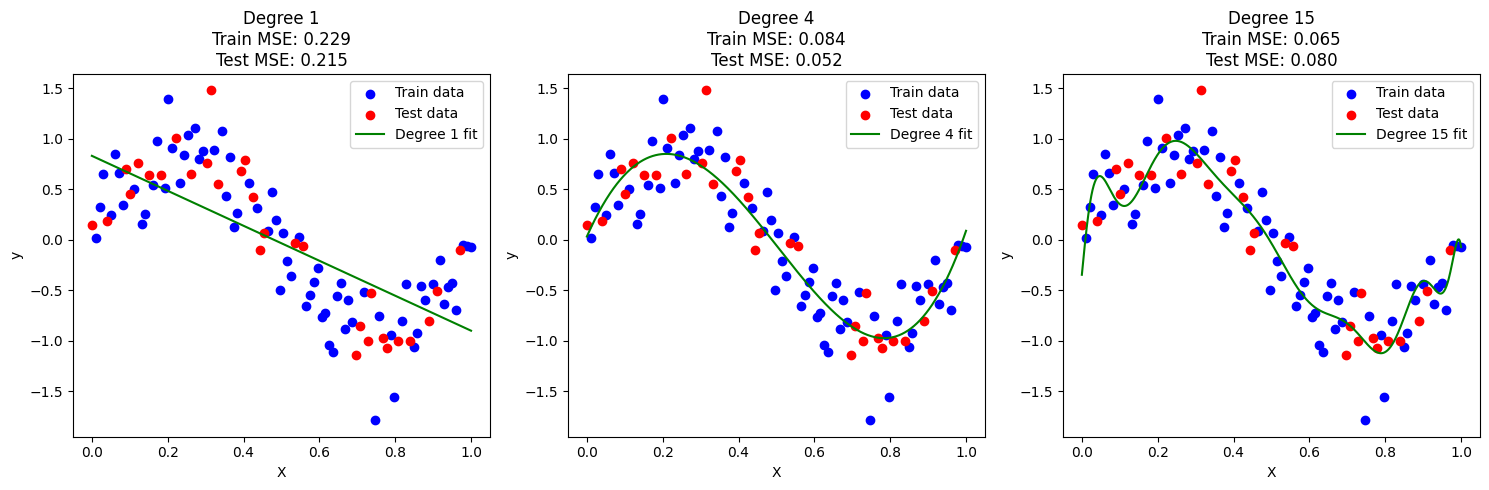

Bias-Variance Analysis:
Degree 1 (High Bias): Train Error = 0.229, Test Error = 0.215
Degree 4 (Balanced): Train Error = 0.084, Test Error = 0.052
Degree 15 (High Variance): Train Error = 0.065, Test Error = 0.080


/var/folders/g3/yq5m9c3d7bn_ff2mgnp1q3rr0000gn/T/ipykernel_77867/3343282525.py:128: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X2_test[:, 0], X2_test[:, 1], c=y2_test, edgecolor='k', cmap='bwr', s=40, alpha=0.6, marker='x', label='test')
/var/folders/g3/yq5m9c3d7bn_ff2mgnp1q3rr0000gn/T/ipykernel_77867/3343282525.py:128: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X2_test[:, 0], X2_test[:, 1], c=y2_test, edgecolor='k', cmap='bwr', s=40, alpha=0.6, marker='x', label='test')
/var/folders/g3/yq5m9c3d7bn_ff2mgnp1q3rr0000gn/T/ipykernel_77867/3343282525.py:128: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor i

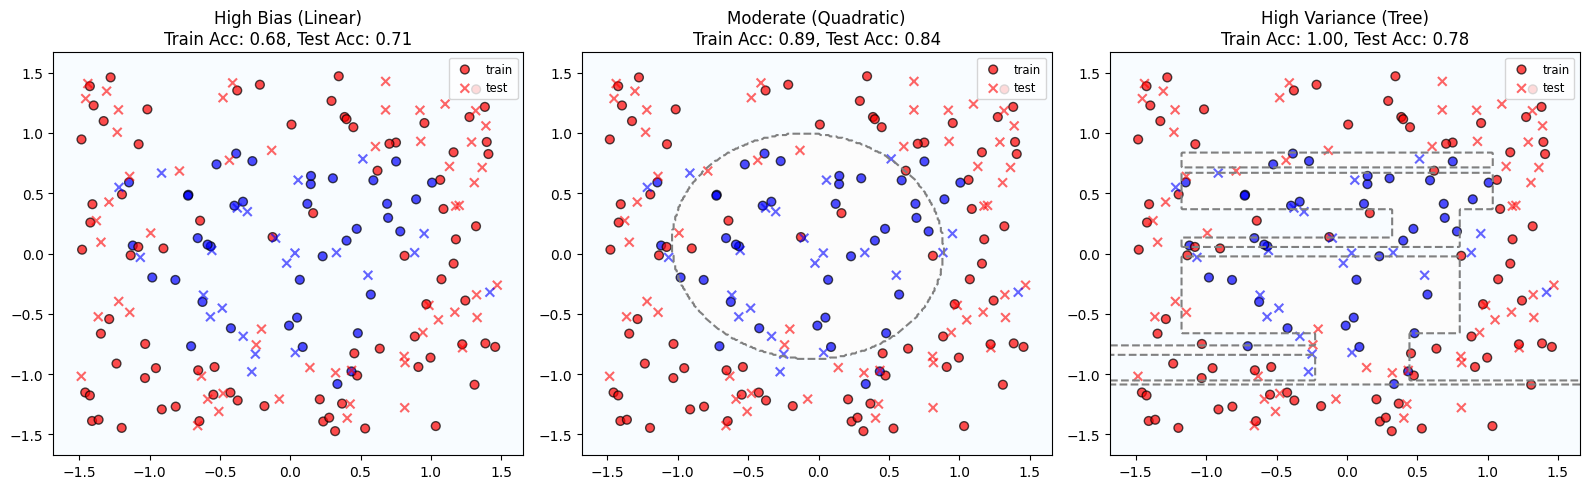

2D classification bias/variance scenarios plotted.


In [2]:
# Example: Demonstrating bias and variance with polynomial regression

# Example: Demonstrating bias and variance with polynomial regression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Generate sample data
np.random.seed(42)
X = np.linspace(0, 1, 100)
y = np.sin(2 * np.pi * X) + 0.3 * np.random.randn(100)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Function to fit polynomial and calculate errors
def fit_polynomial(degree):
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train.reshape(-1, 1))
    X_test_poly = poly.transform(X_test.reshape(-1, 1))
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    train_error = mean_squared_error(y_train, y_train_pred)
    test_error = mean_squared_error(y_test, y_test_pred)
    
    return model, poly, train_error, test_error

# Fit models with different complexities
degrees = [1, 4, 15]  # Low complexity (high bias), medium, high complexity (high variance)
models = []
polys = []
train_errors = []
test_errors = []

for degree in degrees:
    model, poly, train_err, test_err = fit_polynomial(degree)
    models.append(model)
    polys.append(poly)
    train_errors.append(train_err)
    test_errors.append(test_err)

# Plot results
plt.figure(figsize=(15, 5))
X_plot = np.linspace(0, 1, 1000)

for i, (degree, model, poly) in enumerate(zip(degrees, models, polys)):
    plt.subplot(1, 3, i+1)
    plt.scatter(X_train, y_train, color='blue', label='Train data')
    plt.scatter(X_test, y_test, color='red', label='Test data')
    
    X_plot_poly = poly.transform(X_plot.reshape(-1, 1))
    y_plot = model.predict(X_plot_poly)
    plt.plot(X_plot, y_plot, color='green', label=f'Degree {degree} fit')
    
    plt.title(f'Degree {degree}\nTrain MSE: {train_errors[i]:.3f}\nTest MSE: {test_errors[i]:.3f}')
    plt.legend()
    plt.xlabel('X')
    plt.ylabel('y')

plt.tight_layout()
plt.show()

print("Bias-Variance Analysis:")
print(f"Degree 1 (High Bias): Train Error = {train_errors[0]:.3f}, Test Error = {test_errors[0]:.3f}")
print(f"Degree 4 (Balanced): Train Error = {train_errors[1]:.3f}, Test Error = {test_errors[1]:.3f}")
print(f"Degree 15 (High Variance): Train Error = {train_errors[2]:.3f}, Test Error = {test_errors[2]:.3f}")

# --- Add a decision boundary plot for different bias/variance regimes ---
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Create a 2D non-linear classification dataset
np.random.seed(42)
X2 = np.random.uniform(-1.5, 1.5, size=(200, 2))
# non-linear boundary (circle-like) + label noise
y2 = (X2[:, 0]**2 + X2[:, 1]**2 + 0.3 * np.random.randn(200) > 1.0).astype(int)

# forcing an outlier region for high variance demonstration
outlier_indices = np.random.choice(np.arange(200), 7, replace=False)
y2[outlier_indices] = 1 - y2[outlier_indices]

# split for measuring generalization
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.4, random_state=42)

# Define three learner cases
models = [
    ('High Bias (Linear)', make_pipeline(PolynomialFeatures(degree=1), LogisticRegression(solver='liblinear', C=0.1))),
    ('Moderate (Quadratic)', make_pipeline(PolynomialFeatures(degree=2), LogisticRegression(solver='liblinear', C=1.0))),
    ('High Variance (Tree)', DecisionTreeClassifier(max_depth=None, min_samples_leaf=1))
]

# Plot helper
def plot_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
    y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.2, levels=[-0.1, 0.5, 1.1], colors=['#f2f2f2', '#dff2ff'])
    ax.contour(xx, yy, Z, levels=[0.5], colors='grey', linestyles='--')

    # Explicit linear decision boundary for high-bias linear models
    linear_model = None
    if hasattr(model, 'named_steps'):
        linear_model = model.named_steps.get('logisticregression', None)
    elif hasattr(model, 'coef_'):
        linear_model = model

    if linear_model is not None and hasattr(linear_model, 'coef_'):
        coef = linear_model.coef_.ravel()
        intercept = linear_model.intercept_.ravel()[0]
        if coef.shape[0] == 2 and abs(coef[1]) > 1e-8:
            x_line = np.linspace(x_min, x_max, 100)
            y_line = -(coef[0] * x_line + intercept) / coef[1]
            ax.plot(x_line, y_line, 'k-', linewidth=2, label='Linear boundary')

    ax.scatter(X2_train[:, 0], X2_train[:, 1], c=y2_train, edgecolor='k', cmap='bwr', s=40, alpha=0.7, marker='o', label='train')
    ax.scatter(X2_test[:, 0], X2_test[:, 1], c=y2_test, edgecolor='k', cmap='bwr', s=40, alpha=0.6, marker='x', label='test')
    ax.set_title(title)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.legend(loc='upper right', fontsize='small')

plt.figure(figsize=(16, 5))

for i, (name, model) in enumerate(models):
    model.fit(X2_train, y2_train)
    train_acc = model.score(X2_train, y2_train)
    test_acc = model.score(X2_test, y2_test)

    ax = plt.subplot(1, 3, i + 1)
    plot_boundary(ax, model, X2_train, y2_train, f"{name}\nTrain Acc: {train_acc:.2f}, Test Acc: {test_acc:.2f}")

plt.tight_layout()
plt.show()

print('2D classification bias/variance scenarios plotted.')

## Final Solution: Recipe Maps and Relations

This section collects the final “basic recipe” map and the relations between bias/variance diagnosis, causes, and actions.

### Decision map
- Start: train initial model
- If train_error high → High Bias
  - Increase capacity (network size, hidden units/layers)
  - Train longer / better optimizer
  - Try different architecture
- Else if train_error low, dev_error high → High Variance
  - Get more data
  - Apply regularization (L2, dropout, early stop)
  - Simpler model / architecture search
- Else: Low Bias / Low Variance (good)

### Relation table
| Issue | Model behavior | Main signal | Best first action | Secondary action |
|-------|----------------|-------------|--------------------|------------------|
| High Bias | underfit, poor training error | train_err high, dev_err similar | increase model size | better features, longer training |
| High Variance | overfit, train good, dev bad | train_err << dev_err | get more data | regularize/harder norm |
| Balanced | fits both | train_dev gap low | maintain & monitor | minor tuning |

### Lab relation mapping
- Low-degree polynomial on toy data → Bias demonstration
- High-degree polynomial without regularization → Variance demonstration
- L2 regularized high-degree → variance reduction due to regularization
- Increasing dataset fraction → variance reduction via more data

### Implementation notes
- Insert this solution section after the extended experiment visualizations.
- Keep it below, not in the middle, as requested.